# 01 · Predictive Pricing from Features

**Goal:** build the "obvious" pricing model — predict a listing's price (and whether it books) from its features — and feel where that approach hits a ceiling.

This mirrors **Airbnb's** real production design from *Customized Regression Model for Airbnb Dynamic Pricing* (KDD 2018):
1. a **booking-probability** classifier for each listing-night, then
2. a **price** regressor trained with a custom loss that nudges prices up when demand is strong and down when it is weak.

Because no two Airbnb listings are identical, you cannot read a clean demand curve off the market the way you could for a commodity — hence a *model* of value rather than a textbook curve.

**References**
- [Customized Regression Model for Airbnb Dynamic Pricing (KDD 2018)](https://www.kdd.org/kdd2018/accepted-papers/view/customized-regression-model-for-airbnb-dynamic-pricing) · [the morning paper summary](https://blog.acolyer.org/2018/10/03/customized-regression-model-for-airbnb-dynamic-pricing/)
- [Airbnb Engineering — Learning Market Dynamics for Optimal Pricing](https://medium.com/airbnb-engineering/learning-market-dynamics-for-optimal-pricing-97cffbcc53e3)
- Dataset: [NYC Airbnb Open Data (Kaggle)](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)

In [1]:
import sys, os
sys.path.append(os.path.abspath('utils'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import r2_score, mean_absolute_error, roc_auc_score

from datagen import simulate_listings

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Synthetic Airbnb-style listings

We generate listings with a *known* value model (see `utils/datagen.py`). Each listing has a posted `price` and a `booked` outcome.

In [2]:
df, gt = simulate_listings(n=6000, seed=RANDOM_STATE)
print(df.shape)
df.head()

(6000, 11)


,bedrooms,bathrooms,accommodates,location_score,review_score,num_reviews,is_entire_home,day_of_year,season_multiplier,price,booked
0,1,1,3,0.874,3.70,18,1,252,1.110,205.0,1
1,4,5,9,0.246,3.21,23,0,321,0.782,257.0,1
2,3,3,6,0.489,3.60,21,1,218,1.246,331.0,0
3,2,2,4,0.030,4.61,21,1,14,0.709,155.0,1
4,2,2,5,0.009,3.99,26,1,36,0.756,206.0,1


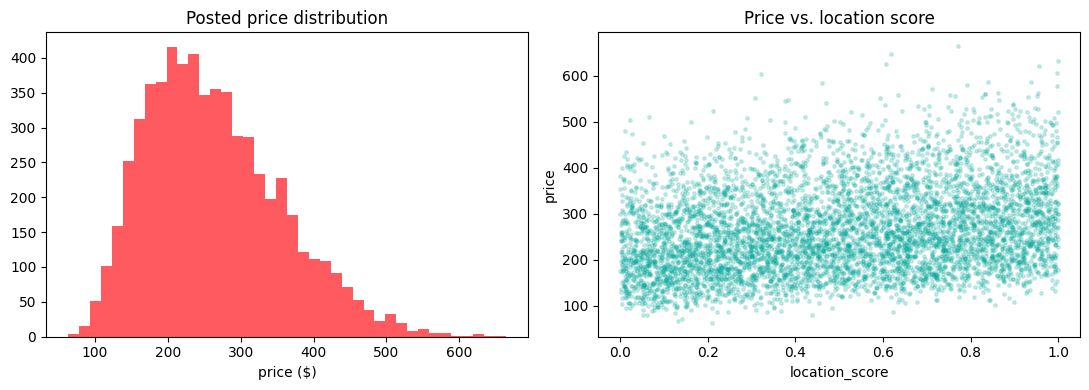

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df['price'], bins=40, color='#FF5A5F')
ax[0].set_title('Posted price distribution'); ax[0].set_xlabel('price ($)')
ax[1].scatter(df['location_score'], df['price'], s=6, alpha=0.2, color='#00A699')
ax[1].set_title('Price vs. location score'); ax[1].set_xlabel('location_score'); ax[1].set_ylabel('price')
plt.tight_layout(); plt.show()

## 2. Stage 1 — booking-probability classifier

Predict `booked` from features **and** the posted price. This is the demand-signal model in Airbnb's design.

In [4]:
feature_cols = ['bedrooms','bathrooms','accommodates','location_score',
                'review_score','num_reviews','is_entire_home','season_multiplier']

Xc = df[feature_cols + ['price']]
yc = df['booked']
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.25, random_state=RANDOM_STATE)

clf = GradientBoostingClassifier(random_state=RANDOM_STATE)
clf.fit(Xc_tr, yc_tr)
auc = roc_auc_score(yc_te, clf.predict_proba(Xc_te)[:,1])
print(f'Booking-probability model AUC: {auc:.3f}')

Booking-probability model AUC: 0.662


## 3. Stage 2 — price regressor

Predict the posted `price` from features. This is a clean supervised problem and the model does well — but read the caveat in section 5 before celebrating.

In [5]:
Xr = df[feature_cols]
yr = df['price']
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.25, random_state=RANDOM_STATE)

reg = GradientBoostingRegressor(random_state=RANDOM_STATE)
reg.fit(Xr_tr, yr_tr)
pred = reg.predict(Xr_te)
print(f'Price model  R^2 : {r2_score(yr_te, pred):.3f}')
print(f'Price model  MAE : ${mean_absolute_error(yr_te, pred):.2f}')

Price model  R^2 : 0.785
Price model  MAE : $32.48


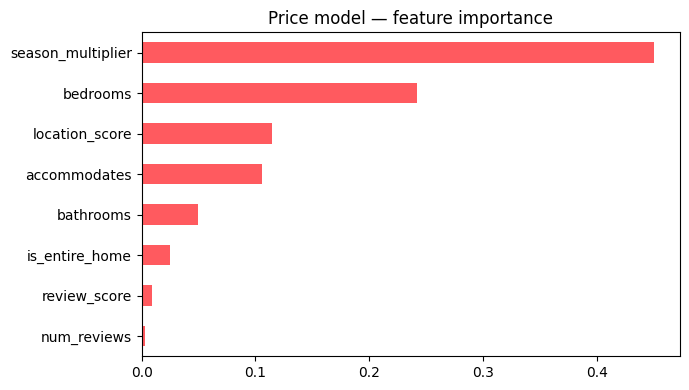

In [6]:
imp = pd.Series(reg.feature_importances_, index=feature_cols).sort_values()
imp.plot.barh(figsize=(7,4), color='#FF5A5F')
plt.title('Price model — feature importance'); plt.tight_layout(); plt.show()

# Sanity check: the true drivers of value should dominate. Seasonality
# multiplies the whole latent value in the simulator, so it ranks alongside
# location and size.
assert imp.idxmax() in {'season_multiplier','location_score','bedrooms','accommodates'}, imp

## 4. Real data (optional, Kaggle)

The same pipeline on the [NYC Airbnb Open Data](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data) set. Needs Kaggle credentials + network; the cell skips gracefully otherwise.

In [7]:
try:
    import kagglehub
    path = kagglehub.dataset_download('dgomonov/new-york-city-airbnb-open-data')
    csv = [f for f in os.listdir(path) if f.endswith('.csv')][0]
    real = pd.read_csv(os.path.join(path, csv))
    real = real[(real['price'] > 10) & (real['price'] < 1000)].copy()
    feats = ['minimum_nights','number_of_reviews','reviews_per_month','availability_365','calculated_host_listings_count']
    real = real.dropna(subset=feats + ['price'])
    Xtr, Xte, ytr, yte = train_test_split(real[feats], real['price'], test_size=0.25, random_state=RANDOM_STATE)
    m = GradientBoostingRegressor(random_state=RANDOM_STATE).fit(Xtr, ytr)
    print(f'Real NYC Airbnb  R^2: {r2_score(yte, m.predict(Xte)):.3f}')
except Exception as e:
    print('Skipping Kaggle real-data section (no network/credentials):', type(e).__name__, e)

  0%|          | 0.00/2.44M [00:00<?, ?B/s]

100%|██████████| 2.44M/2.44M [00:00<00:00, 95.4MB/s]

Extracting files...


Real NYC Airbnb  R^2: 0.124


## 5. The catch — prediction ≠ pricing power

Our price model has a high R². But look at what it actually learned: it predicts the price a host **already posted** from features. It answers *"what is the going rate for a listing like this?"* — useful for a price *tip*.

It does **not** answer the question that actually sets revenue:

> If I **raise** this listing's price by \$20, how much will my booking probability **fall**?

That is a question about a **demand curve** — how quantity *responds* to a *change* in price. A predictor trained on observed prices has never seen a controlled price change; it has only seen equilibrium outcomes. To price well we need the **price elasticity of demand**, which is the subject of [notebook 02](02_elasticity_supply_demand.ipynb).